# Exercises XP Gold - K-means from scratch

## What you will create
- A K-means implementation in pure NumPy.
- Scatter plots of clusters and centroid convergence.
- A report with cluster assignments per point.
- A random centroid initializer to study initialization impact.

## What you will learn
- Euclidean distance and closest-centroid assignment.
- How centroid updates reduce within-cluster variance.
- Why initialization matters and how to evaluate runs.


## Task 1 - Load and visualize the dataset
Dataset: `ex7data2.mat` contains an array `X` of shape (m, 2).

- Load with `scipy.io.loadmat`
- Inspect shape and preview first rows
- Scatter plot of points

Shape of X: (300, 2)
First 5 rows of X:
[[1.84207953 4.6075716 ]
 [5.65858312 4.79996405]
 [6.35257892 3.2908545 ]
 [2.90401653 4.61220411]
 [3.23197916 4.93989405]]


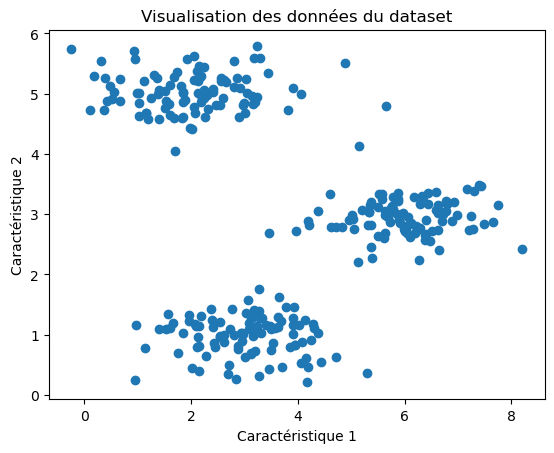

In [ ]:
# TODO: load X from the .mat file
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

mat_path = 'ex7data2.mat'
data = loadmat(mat_path)
#print(data)
# TODO: set X to the numpy array of points
X = data['X']   # TODO
print('Shape of X:', X.shape)  
# TODO: preview first 5 rows
print(f'First 5 rows of X:')
print(X[:5])

#TODO: scatter plot
plt.figure()
plt.scatter(X[:, 0], X[:, 1])
plt.title("Visualisation des données du dataset")
plt.xlabel("Caractéristique 1")
plt.ylabel("Caractéristique 2")
plt.show()

## Task 2 - Finding closest centroids
Implement `find_closest_centroids(X, centroids)`.

- Input: X shape (m, n), centroids shape (K, n)
- Output: idx shape (m,), integer cluster index in [0, K-1] for each point
- Use squared Euclidean distances

Test with initial centroids = `np.array([[3, 3], [6, 2], [8, 5]])` and print the first three indices.

In [6]:
# TODO: implement
def find_closest_centroids(X, centroids):
    """Return idx of shape (m,) with index of closest centroid for each point."""
    # TODO: compute distances of shape (m, K) using broadcasting
    distances = np.sum((X[:, np.newaxis, :] - centroids) ** 2, axis=2)  # TODO
    idx = np.argmin(distances, axis=1)        # TODO: np.argmin over axis=1
    return idx

# Test
import numpy as np
init_centroids = np.array([[3,3],[6,2],[8,5]], dtype=float)
idx = find_closest_centroids(X, init_centroids)
print(idx[:3])

[0 2 1]


## Task 3 - Computing centroids
Implement `compute_centroids(X, idx, K)`.

- For each k in 0..K-1 compute the mean of points assigned to k
- Return `centroids` of shape (K, n)
- If a cluster is empty, reinitialize its centroid by sampling a random point from X

In [7]:
def compute_centroids(X, idx, K, rng=None):
    m, n = X.shape
    new_centroids = np.zeros((K, n), dtype=float)
    rng = np.random.default_rng() if rng is None else rng
    
    for k in range(K):
        # 1. Sélection des points assignés au cluster k
        pts = X[idx == k]
        
        if pts.shape[0] == 0:
            # Cas critique : Aucun point n'est assigné à ce centre.
            # On pioche un indice au hasard entre 0 et m-1.
            random_idx = rng.integers(0, m)
            # Le nouveau centre prend la position de ce point tiré au sort.
            new_centroids[k] = X[random_idx]
        else:
            # Cas normal : On calcule la moyenne des coordonnées des points.
            # axis=0 permet de faire la moyenne colonne par colonne (X puis Y).
            new_centroids[k] = np.mean(pts, axis=0)
            
    return new_centroids

## Task 4 - Running K-means
Implement `run_k_means(X, init_centroids, max_iters)`.

- Loop: assign then update
- Keep history of centroids for plotting
- Return final centroids, idx, and history list
- Run for 10 iterations and plot clusters with final centroids

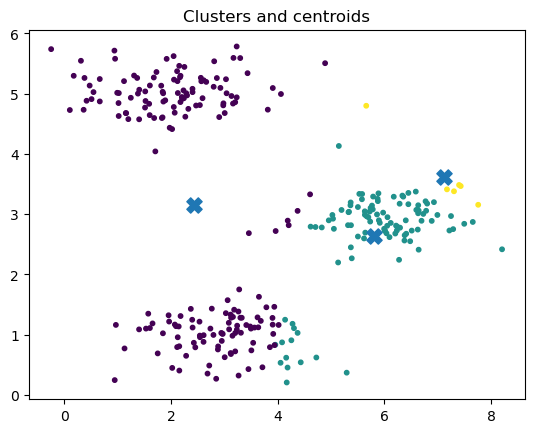

In [8]:
# TODO: implement
def run_k_means(X, init_centroids, max_iters=10, rng=None):
    K = init_centroids.shape[0]
    centroids = init_centroids.copy().astype(float)
    history = [centroids.copy()]
    idx = None
    for it in range(max_iters):
    # 1. On trouve les centres les plus proches pour chaque point
     idx = find_closest_centroids(X, centroids)
    
    # 2. On calcule la nouvelle position des centres
    centroids = compute_centroids(X, idx, K, rng=rng)
    
    # 3. On enregistre cette nouvelle position dans l'historique
    history.append(centroids.copy())
    pass
    return centroids, idx, history

# Example run
final_centroids, idx, hist = run_k_means(X, init_centroids, max_iters=10)
import matplotlib.pyplot as plt
plt.figure(); plt.scatter(X[:,0], X[:,1], c=idx, s=10)
plt.scatter(final_centroids[:,0], final_centroids[:,1], marker='X', s=120)
plt.title('Clusters and centroids'); plt.show()

## Task 5 - Initializing centroids
Implement `init_centroids(X, K, rng)` that picks K distinct random points from X.

Test by printing initial centroids for K = 3.

In [12]:
# TODO: implement
def init_centroids(X, K, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    m = X.shape[0]
    idx = rng.choice(m, size=K, replace=False)
    return X[idx].astype(float)
    raise NotImplementedError

    print(init_centroids(X, 3))

## Task 6 - Multiple initializations and evaluation
Define an inertia function `withinss(X, centroids, idx)` to compute the sum of squared distances to centroids.

- Run K-means for several random seeds
- Keep the run with lowest inertia
- Save a CSV report with x1, x2, cluster label

In [15]:
# TODO: implement inertia and multi-start search
def withinss(X, centroids, idx):
    assigned_centroids = centroids[idx]
    diffs = X - assigned_centroids
    return float(np.sum(diffs * diffs))
    #return None

best = {'score': np.inf}
for seed in range(5):
    rng = np.random.default_rng(seed)
    c0 = init_centroids(X, 3, rng)
    cF, idxF, hist = run_k_means(X, c0, max_iters=10, rng=rng)
    s = withinss(X, cF, idxF)
    if s < best['score']:
        best = {'score': s, 'centroids': cF, 'idx': idxF}
print('Best inertia:', best['score'])

import pandas as pd
rep = pd.DataFrame({'x1': X[:,0], 'x2': X[:,1], 'cluster': best['idx']})
rep.to_csv('kmeans_assignments.csv', index=False)
print('Wrote kmeans_assignments.csv')

Best inertia: 726.6164822735198
Wrote kmeans_assignments.csv
